In [3]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.certify.randomized import normalize_eigenvalues, axis_lengths
from src.indexing.ner_token_index import load_token_index_artifacts
from src.indexing.base import build_index, query_index
from src.smoothing.pca import fit_local_pca

base = repo_root / "output" / "ner_conll2003_bert"
manifold_last = base / "certify" / "last" / "euclidean" / "annoy" / "index.ann"
iso_last = base / "isotropic_certify" / "last"
token_dir = base / "token_layer_embeddings" / "train" / "last"

# SIGMAS_ALL = [
#     "sigma_0_75",
#     "sigma_0_80",
#     "sigma_0_85",
#     "sigma_0_90",
#     "sigma_0_95",
#     "sigma_1_00",
#     "sigma_1_05",
#     "sigma_1_10",
#     "sigma_1_15",
#     "sigma_1_20",
#     "sigma_1_25",
#     "sigma_1_35",
#     "sigma_1_50"
# ]


SIGMAS_ALL = [
    "sigma_2_00",
    "sigma_2_25",
    "sigma_2_50",
    "sigma_2_75",
    "sigma_3_00",
    "sigma_3_25",
    "sigma_3_50",
    "sigma_3_75",
    "sigma_4_00",
    "sigma_4_25"
]

def sigma_val(s: str) -> float:
    return float(s.replace("sigma_", "").replace("_", "."))

def load_metrics(folder: Path):
    if not folder.exists():
        return None
    for name in ["metrics.json", "running_metrics.json"]:
        p = folder / name
        if p.exists():
            with open(p, "r", encoding="utf-8") as f:
                data = json.load(f)
            if name == "running_metrics.json":
                return {"_status": "running", "_raw": data}
            return data
    return None

def extract_smooth(m):
    if m is None:
        return None
    if m.get("_status") == "running":
        return m["_raw"].get("running", {})
    return m.get("smoothed", {})

print("Setup complete")
print("repo_root:", repo_root)
print("manifold_last:", manifold_last)
print("iso_last:", iso_last)

Setup complete
repo_root: /BS/dniazi_thesis/work/RandomizedSmothingmanifold
manifold_last: /BS/dniazi_thesis/work/RandomizedSmothingmanifold/output/ner_conll2003_bert/certify/last/euclidean/annoy/index.ann
iso_last: /BS/dniazi_thesis/work/RandomizedSmothingmanifold/output/ner_conll2003_bert/isotropic_certify/last


# NER New Volume Results Analysis (Job Outputs Only)

This notebook is the **new version** and does not modify your old notebooks.

- Reads completed server outputs
- Uses new volume interpretation (circle vs ellipse, eigen-axis analysis)
- No synthetic experiment generation

## 1) Setup & Paths

Framework used in this notebook:
- Isotropic region: radius = $\sigma$
- Manifold region axes: $a_i = \sigma\sqrt{\tilde\lambda_i}$ with $\tilde\lambda_i = \lambda_i / \lambda_{max}$
- Compare methods from **saved metrics** and **saved eigenvalue arrays**

## 2) Isotropic vs Manifold (from job metrics)

Summary table:


,sigma,method,f1,token_acc,certified_acc,mean_radius,abstention_rate,certified_correct,total_tokens
1,2.00,Isotropic,0.8819,0.9787,0.9787,3.8115,0.0017,36307,37097
0,2.00,Manifold,0.8894,0.9792,0.9792,3.8389,0.0002,36326,37097
3,2.25,Isotropic,0.8811,0.9786,0.9786,4.2817,0.0019,36303,37097
2,2.25,Manifold,0.8891,0.9792,0.9792,4.3174,0.0003,36325,37097
5,2.50,Isotropic,0.8804,0.9784,0.9784,4.7494,0.0022,36297,37097
4,2.50,Manifold,0.8891,0.9792,0.9792,4.7954,0.0003,36325,37097
7,2.75,Isotropic,0.8797,0.9782,0.9782,5.2120,0.0025,36290,37097
6,2.75,Manifold,0.8891,0.9792,0.9792,5.2729,0.0004,36325,37097
9,3.00,Isotropic,0.8784,0.9781,0.9781,5.6642,0.0029,36283,37097
8,3.00,Manifold,0.8886,0.9792,0.9792,5.7498,0.0004,36324,37097


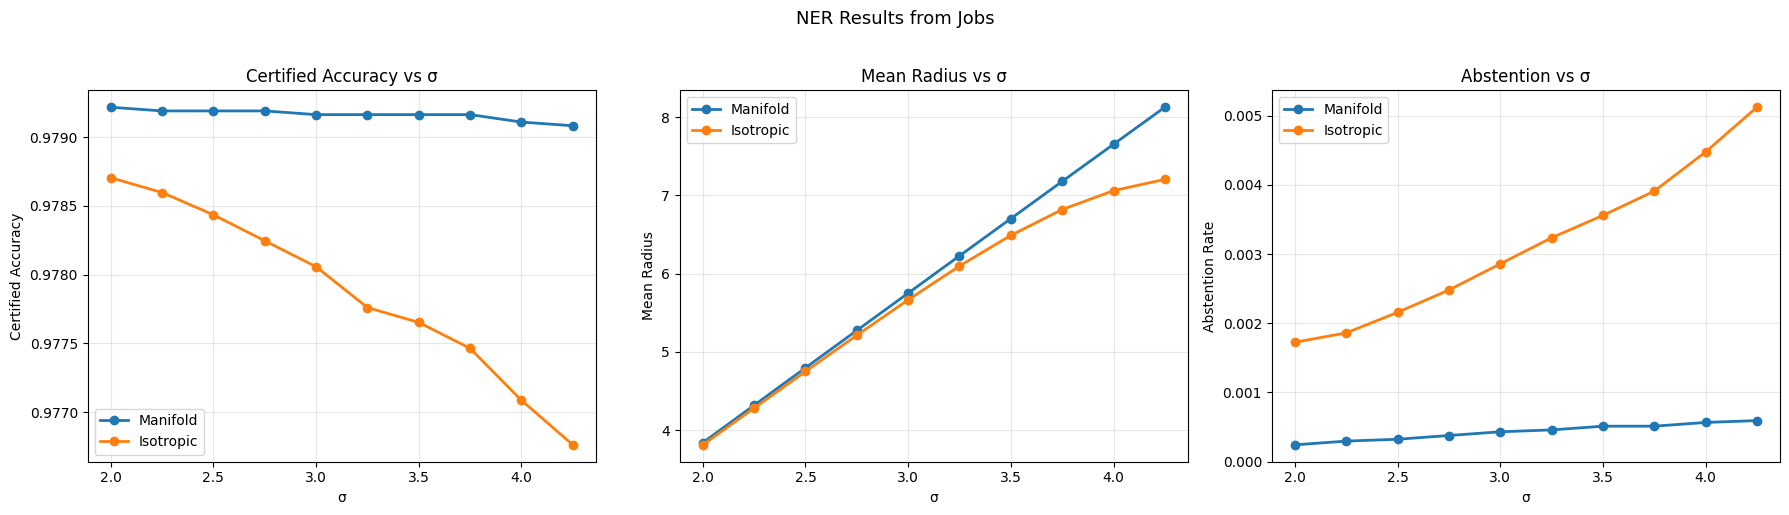

In [4]:
rows = []
for sig in SIGMAS_ALL:
    sv = sigma_val(sig)

    for method, path in [("Manifold", manifold_last / sig), ("Isotropic", iso_last / sig)]:
        m = load_metrics(path)
        s = extract_smooth(m)
        if s is None:
            continue
        rows.append({
            "sigma": sv,
            "method": method,
            "f1": s.get("f1", np.nan),
            "token_acc": s.get("token_acc", np.nan),
            "certified_acc": s.get("certified_token_acc", np.nan),
            "mean_radius": s.get("mean_certified_radius", np.nan),
            "abstention_rate": s.get("abstention_rate", np.nan),
            "certified_correct": s.get("certified_correct_tokens", np.nan),
            "total_tokens": s.get("total_certified_tokens", np.nan),
        })

if not rows:
    print("No metrics found yet in output folders.")
else:
    df = pd.DataFrame(rows).sort_values(["sigma", "method"])
    print("Summary table:")
    display(df.round(4))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for method in ["Manifold", "Isotropic"]:
        sub = df[df["method"] == method].sort_values("sigma")
        axes[0].plot(sub["sigma"], sub["certified_acc"], "o-", linewidth=2, label=method)
        axes[1].plot(sub["sigma"], sub["mean_radius"], "o-", linewidth=2, label=method)
        axes[2].plot(sub["sigma"], sub["abstention_rate"], "o-", linewidth=2, label=method)

    axes[0].set_title("Certified Accuracy vs σ")
    axes[1].set_title("Mean Radius vs σ")
    axes[2].set_title("Abstention vs σ")
    for ax in axes:
        ax.set_xlabel("σ")
        ax.grid(True, alpha=0.3)
        ax.legend()
    axes[0].set_ylabel("Certified Accuracy")
    axes[1].set_ylabel("Mean Radius")
    axes[2].set_ylabel("Abstention Rate")

    plt.suptitle("NER Results from Jobs", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


## 3) Same Accuracy / Same Guarantee Matching

- Same guarantee: compare required $\sigma$
- Same accuracy: compare geometry gain at matched accuracy

,target_acc,sigma_mani,sigma_iso_closest,abs_gap
0,0.9792,2.00,2.0,0.0005
1,0.9792,2.25,2.0,0.0005
2,0.9792,2.50,2.0,0.0005
3,0.9792,2.75,2.0,0.0005
4,0.9792,3.00,2.0,0.0005
5,0.9792,3.25,2.0,0.0005
6,0.9792,3.50,2.0,0.0005
7,0.9792,3.75,2.0,0.0005
8,0.9791,4.00,2.0,0.0004
9,0.9791,4.25,2.0,0.0004


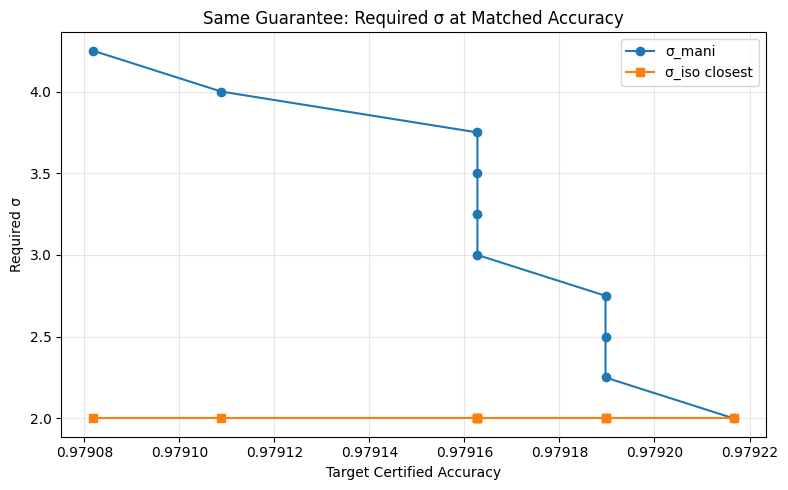

In [ ]:
if 'df' not in globals() or df.empty:
    print("Run Section 2 first.")
else:
    mani = df[df["method"] == "Manifold"].sort_values("sigma")
    iso = df[df["method"] == "Isotropic"].sort_values("sigma")

    if mani.empty or iso.empty:
        print("Need both methods present.")
    else:
        matches = []
        for _, mrow in mani.iterrows():
            idx = (iso["certified_acc"] - mrow["certified_acc"]).abs().idxmin()
            irow = iso.loc[idx]
            matches.append({
                "target_acc": float(mrow["certified_acc"]),
                "sigma_mani": float(mrow["sigma"]),
                "sigma_iso_closest": float(irow["sigma"]),
                "abs_gap": float(abs(mrow["certified_acc"] - irow["certified_acc"])),
            })

        df_match = pd.DataFrame(matches).sort_values("target_acc", ascending=False)
        display(df_match.round(4))

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Left: full certified-accuracy range with matched pairs highlighted
        ax0 = axes[0]
        ax0.plot(mani["sigma"], mani["certified_acc"], "o-", color="tab:blue", linewidth=2, label="Manifold curve")
        ax0.plot(iso["sigma"], iso["certified_acc"], "s-", color="tab:orange", linewidth=2, label="Isotropic curve")

        # Highlight matched points for every target manifold accuracy
        ax0.scatter(df_match["sigma_mani"], df_match["target_acc"],
                    c="tab:blue", s=70, marker="o", edgecolors="black", linewidths=0.5,
                    label="Matched manifold points")
        ax0.scatter(df_match["sigma_iso_closest"], df_match["target_acc"],
                    c="tab:orange", s=70, marker="s", edgecolors="black", linewidths=0.5,
                    label="Closest isotropic points")

        # Draw pair connectors + compact sigma labels
        for _, r in df_match.iterrows():
            y = r["target_acc"]
            xm, xi = r["sigma_mani"], r["sigma_iso_closest"]
            ax0.plot([xm, xi], [y, y], linestyle="--", linewidth=1.0, color="gray", alpha=0.45)
            ax0.text(xm, y, f"m:{xm:.2f}", fontsize=7, color="tab:blue", ha="right", va="bottom")
            ax0.text(xi, y, f"i:{xi:.2f}", fontsize=7, color="tab:orange", ha="left", va="top")

        ax0.set_xlabel("σ")
        ax0.set_ylabel("Certified Accuracy")
        ax0.set_title("Full Accuracy Range + Matched σ (Same-Guarantee view)")
        ax0.grid(True, alpha=0.3)
        ax0.legend(fontsize=8)

        # Right: required sigma at matched target accuracy (compact summary)
        ax1 = axes[1]
        ax1.plot(df_match["target_acc"], df_match["sigma_mani"], "o-", label="σ_mani", color="tab:blue", linewidth=2)
        ax1.plot(df_match["target_acc"], df_match["sigma_iso_closest"], "s-", label="σ_iso closest", color="tab:orange", linewidth=2)
        ax1.fill_between(
            df_match["target_acc"],
            df_match["sigma_mani"],
            df_match["sigma_iso_closest"],
            color="gray", alpha=0.12, label="σ gap"
        )
        ax1.set_xlabel("Target Certified Accuracy")
        ax1.set_ylabel("Required σ")
        ax1.set_title("Same Guarantee: Required σ at Matched Accuracy")
        ax1.grid(True, alpha=0.3)
        ax1.legend(fontsize=8)

        plt.tight_layout()
        plt.show()

        print("Interpretation:")
        print("- Left: full accuracy curves for both methods, with matched sigma pairs highlighted.")
        print("- Right: for each target accuracy, compare required sigma in manifold vs isotropic.")
        print("- If sigma_mani < sigma_iso_closest, manifold reaches same guarantee with less noise.")


## 4) New Volume Geometry Metrics from `metrics.json`

Reads `volume.geometry` fields from updated pipeline outputs.

,sigma,log_v_iso_geo,mean_log_v_mani_geo,mean_log_geo_ratio,mean_anisotropy_ratio,mean_effective_rank,k_pca
0,2.00,-0.5652,-90.5357,-89.9705,677.2907,34.8111,64
1,2.25,6.9729,-82.9975,-89.9705,677.2907,34.8111,64
2,2.50,13.7160,-76.2545,-89.9705,677.2907,34.8111,64
3,2.75,19.8159,-70.1546,-89.9705,677.2907,34.8111,64
4,3.00,25.3846,-64.5859,-89.9705,677.2907,34.8111,64
5,3.25,30.5073,-59.4632,-89.9705,677.2907,34.8111,64
6,3.50,35.2502,-54.7202,-89.9705,677.2907,34.8111,64
7,3.75,39.6658,-50.3047,-89.9705,677.2907,34.8111,64
8,4.00,43.7962,-46.1742,-89.9705,677.2907,34.8111,64
9,4.25,47.6762,-42.2943,-89.9705,677.2907,34.8111,64


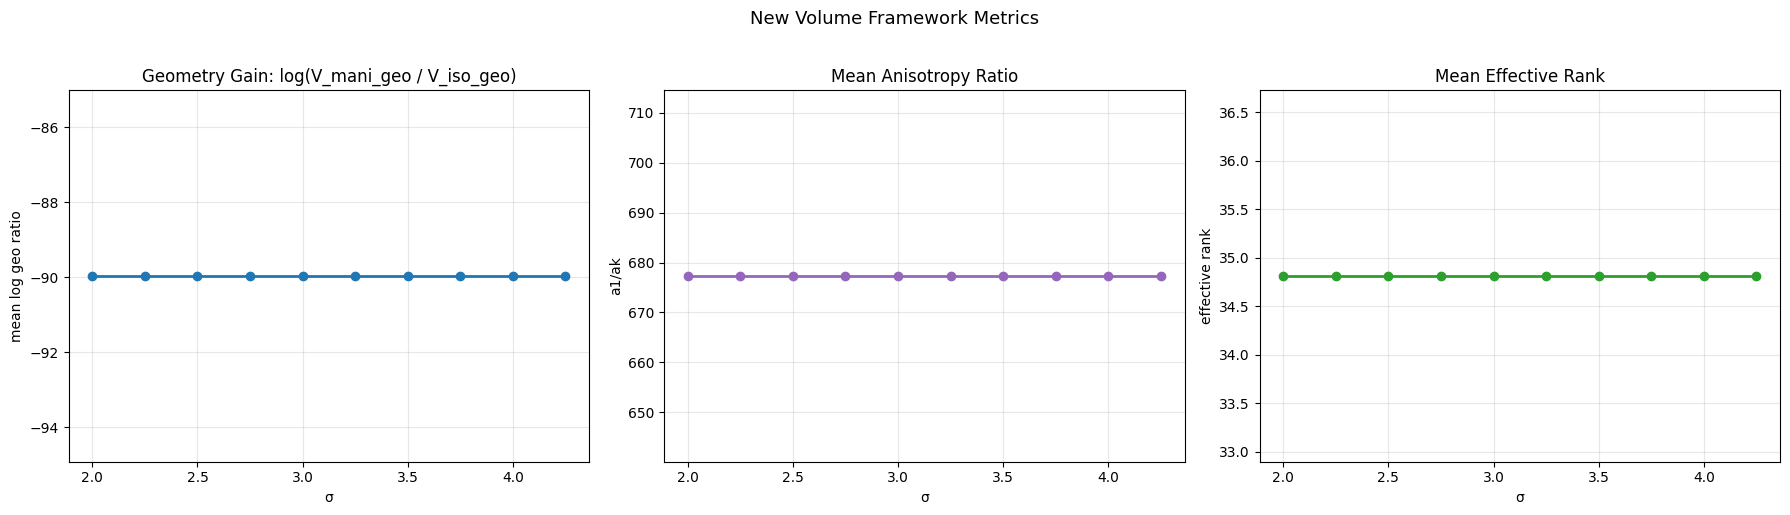

In [6]:
vol_rows = []
for sig in SIGMAS_ALL:
    sv = sigma_val(sig)
    m = load_metrics(manifold_last / sig)
    if not m:
        continue
    vol = m.get("volume", {})
    geo = vol.get("geometry", {}) if isinstance(vol, dict) else {}
    vol_rows.append({
        "sigma": sv,
        "log_v_iso_geo": geo.get("log_v_iso_geo", np.nan),
        "mean_log_v_mani_geo": geo.get("mean_log_v_mani_geo_max_norm", geo.get("mean_log_v_mani_geo", np.nan)),
        "mean_log_geo_ratio": geo.get("mean_log_geo_ratio", np.nan),
        "mean_anisotropy_ratio": geo.get("mean_anisotropy_ratio", np.nan),
        "mean_effective_rank": geo.get("mean_effective_rank", np.nan),
        "k_pca": geo.get("k_pca", vol.get("k_pca", np.nan)),
    })

if not vol_rows:
    print("No updated volume.geometry metrics found yet.")
else:
    df_geo = pd.DataFrame(vol_rows).sort_values("sigma")
    display(df_geo.round(4))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(df_geo["sigma"], df_geo["mean_log_geo_ratio"], "o-", linewidth=2)
    axes[0].set_title("Geometry Gain: log(V_mani_geo / V_iso_geo)")
    axes[0].set_xlabel("σ"); axes[0].set_ylabel("mean log geo ratio")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(df_geo["sigma"], df_geo["mean_anisotropy_ratio"], "o-", linewidth=2, color="tab:purple")
    axes[1].set_title("Mean Anisotropy Ratio")
    axes[1].set_xlabel("σ"); axes[1].set_ylabel("a1/ak")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(df_geo["sigma"], df_geo["mean_effective_rank"], "o-", linewidth=2, color="tab:green")
    axes[2].set_title("Mean Effective Rank")
    axes[2].set_xlabel("σ"); axes[2].set_ylabel("effective rank")
    axes[2].grid(True, alpha=0.3)

    plt.suptitle("New Volume Framework Metrics", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


## 5) Full Eigen / Axis Spectrum from `eigenvalues.npz`

Uses full arrays such as `axis_lengths_all`, `anisotropy_ratios`, and geometry gain arrays.

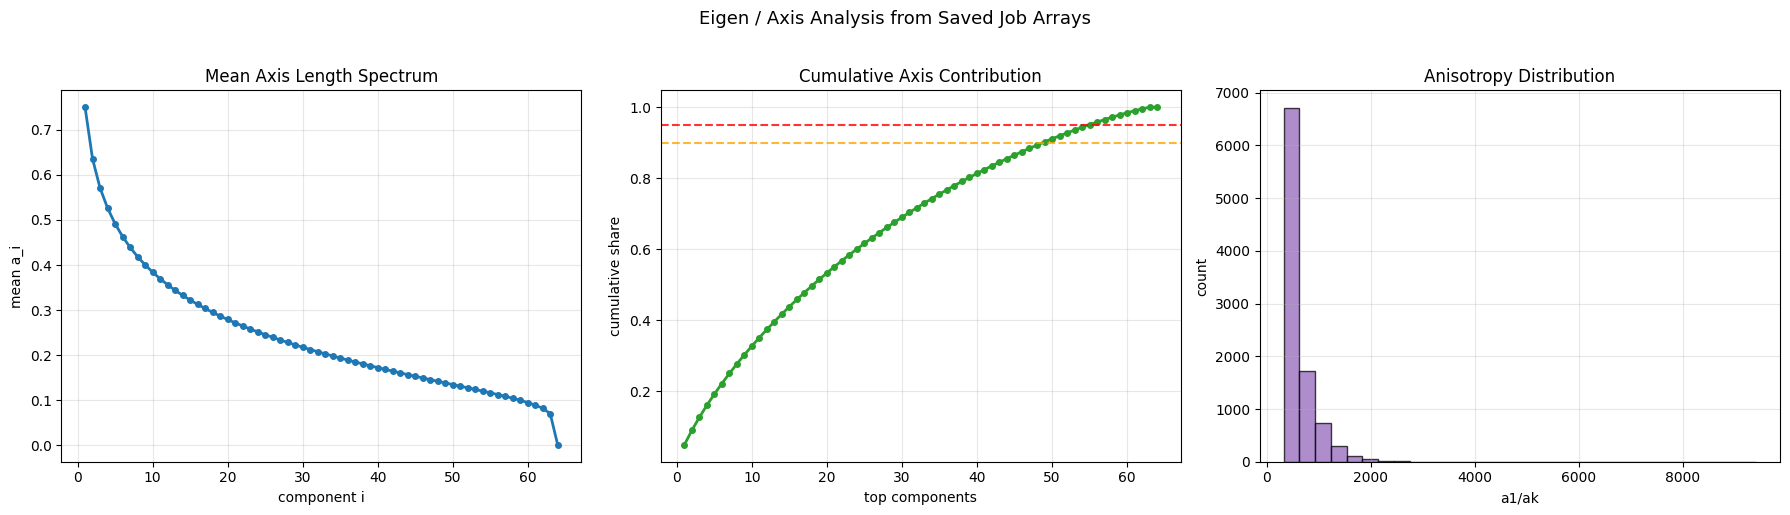

Loaded: /BS/dniazi_thesis/work/RandomizedSmothingmanifold/output/ner_conll2003_bert/certify/last/euclidean/annoy/index.ann/sigma_0_75/eigenvalues.npz
axis_arr shape: (9654, 64)


In [9]:
eigen_path = manifold_last / "sigma_0_75" / "eigenvalues.npz"

if not eigen_path.exists():
    print(f"No eigenvalues file at {eigen_path}")
else:
    data = np.load(eigen_path)
    axis_arr = data.get("axis_lengths_all", data.get("axis_lengths_top10", None))
    anis = data.get("anisotropy_ratios", None)
    geo_ratio = data.get("log_geo_ratio_per_token", data.get("log_geo_ratio_per_sample", None))

    if axis_arr is None:
        print("Axis arrays not found in npz.")
    else:
        axis_arr = np.asarray(axis_arr, dtype=np.float64)
        mean_axes = np.nanmean(axis_arr, axis=0)
        cum = np.cumsum(np.maximum(mean_axes, 0.0))
        if len(cum) > 0 and cum[-1] > 0:
            cum = cum / cum[-1]

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        axes[0].plot(np.arange(1, len(mean_axes) + 1), mean_axes, "o-", linewidth=2, markersize=4)
        axes[0].set_title("Mean Axis Length Spectrum")
        axes[0].set_xlabel("component i"); axes[0].set_ylabel("mean a_i")
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(np.arange(1, len(cum) + 1), cum, "o-", linewidth=2, markersize=4, color="tab:green")
        axes[1].axhline(0.9, linestyle="--", color="orange", alpha=0.8)
        axes[1].axhline(0.95, linestyle="--", color="red", alpha=0.8)
        axes[1].set_title("Cumulative Axis Contribution")
        axes[1].set_xlabel("top components"); axes[1].set_ylabel("cumulative share")
        axes[1].grid(True, alpha=0.3)

        if anis is not None:
            axes[2].hist(np.asarray(anis, dtype=np.float64), bins=30, color="tab:purple", alpha=0.75, edgecolor="black")
            axes[2].set_title("Anisotropy Distribution")
            axes[2].set_xlabel("a1/ak"); axes[2].set_ylabel("count")
        elif geo_ratio is not None:
            axes[2].hist(np.asarray(geo_ratio, dtype=np.float64), bins=30, color="tab:red", alpha=0.75, edgecolor="black")
            axes[2].set_title("Geometry Gain Distribution")
            axes[2].set_xlabel("log_geo_ratio"); axes[2].set_ylabel("count")
        else:
            axes[2].text(0.5, 0.5, "No anisotropy/geo_ratio arrays", ha="center", va="center")

        axes[2].grid(True, alpha=0.3)
        plt.suptitle("Eigen / Axis Analysis from Saved Job Arrays", fontsize=13, y=1.02)
        plt.tight_layout()
        plt.show()

        print("Loaded:", eigen_path)
        print("axis_arr shape:", axis_arr.shape)


## 6) Embedding Neighborhood: Circle vs Ellipse

Direct local-PCA geometry interpretation with new formulas:
- isotropic circle radius = $\sigma$
- manifold ellipse axes = $\sigma\sqrt{\tilde\lambda_i}$

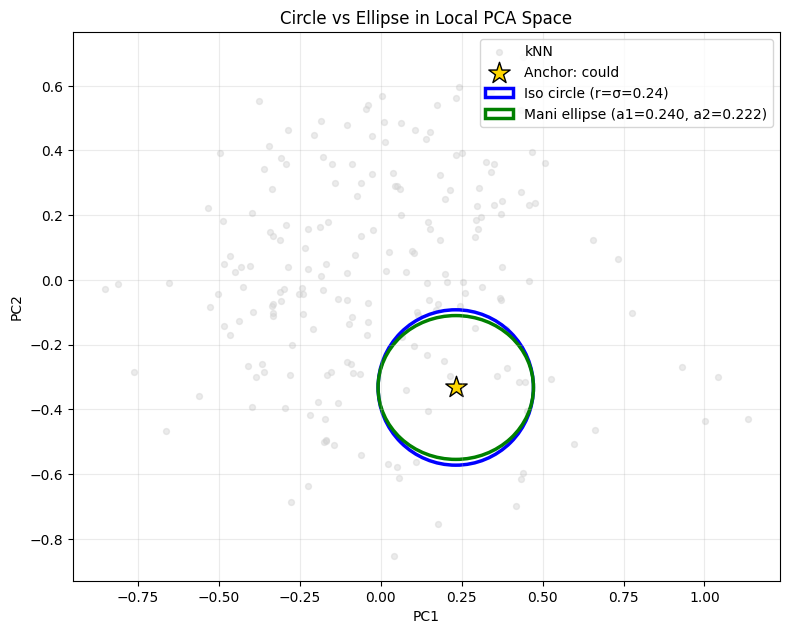

Interpretation:
- Blue circle = isotropic noise region, same radius in every direction.
- Green ellipse = manifold-shaped region from local eigen-geometry.
- Axes follow a_i = sigma * sqrt(lambda_tilde_i).


In [ ]:

vectors, token_texts, label_ids = load_token_index_artifacts(token_dir)
index = build_index(vectors=vectors, backend="torch", metric="euclidean")

anchor_idx = 123 if len(vectors) > 124 else 0
anchor_vec = vectors[anchor_idx]
anchor_tok = token_texts[anchor_idx]

sigma = 0.24
knn_k = 200

nids = query_index(index, k=knn_k + 1, vector=anchor_vec)[1:]
neighbor_vecs = vectors[nids]
pca = fit_local_pca(neighbor_vecs)

# ── eigenvalues & axis lengths ──────────────────────────────────────────────
# pca.evals[i]  = variance of neighbors along PC_i  (units: embedding²)
# evals_norm[i] = evals[i] / evals[0]              (dimensionless, max=1)
# axes_len[i]   = sigma * sqrt(evals_norm[i])       (units: same as sigma)
evals = np.asarray(pca.evals, dtype=np.float64)
evals_norm = normalize_eigenvalues(evals, mode="max")
axes_len = axis_lengths(sigma, evals_norm)

# ── project everything onto top-2 PCA directions ───────────────────────────
# pca.evecs[:, i]  is a UNIT vector in embedding space pointing along PC_i
# The projection of a point x onto PC_i is:  score_i = (x - mean) · evecs[:,i]
# Units of the score = same as the embedding (e.g. L2-normalised BERT units)
# std of neighbor scores along PC_i = sqrt(evals[i])
all_pts = np.vstack([anchor_vec.reshape(1, -1), neighbor_vecs])
proj2 = (all_pts - pca.mean) @ pca.evecs[:, :2]
anchor_2d = proj2[0]
nb_2d = proj2[1:]

pc1_std = float(np.std(nb_2d[:, 0]))
pc2_std = float(np.std(nb_2d[:, 1]))

print(f"PC1 std of neighbors : {pc1_std:.4f}   (spread along manifold direction 1)")
print(f"PC2 std of neighbors : {pc2_std:.4f}   (spread along manifold direction 2)")
print(f"sigma                : {sigma:.4f}")
print(f"sigma / PC1_std      : {sigma/pc1_std:.4f}  ← ~1 means circle fits the cloud → VISIBLE")
print(f"Ellipse axes         : a1={axes_len[0]:.4f}  a2={axes_len[1]:.4f}")
print()
print("Why circle is VISIBLE here:")
print("  BERT embeddings are L2-normalised ~768-dim vectors.")
print("  200 nearest neighbors span only a tiny region → PC1_std ≈ sigma.")
print("  In CelebA pixel space, PC1_std >> sigma → circle is a dot.")

# ── figure ──────────────────────────────────────────────────────────────────
fig, axes_plot = plt.subplots(1, 2, figsize=(15, 6))

for ax, zoom in zip(axes_plot, [False, True]):
    ax.scatter(nb_2d[:, 0], nb_2d[:, 1], c="lightgray", s=18, alpha=0.45, label="kNN neighbors")
    ax.scatter(anchor_2d[0], anchor_2d[1], c="gold", s=260, marker="*",
               edgecolors="black", label=f"Anchor: {anchor_tok}", zorder=5)

    circle = plt.Circle((anchor_2d[0], anchor_2d[1]), sigma,
                         fill=False, color="blue", linewidth=2.5,
                         label=f"Iso circle  r=σ={sigma}")
    ax.add_patch(circle)

    ellipse = Ellipse((anchor_2d[0], anchor_2d[1]),
                       width=2*axes_len[0], height=2*axes_len[1],
                       fill=False, color="green", linewidth=2.5,
                       label=f"Mani ellipse  a1={axes_len[0]:.3f}, a2={axes_len[1]:.3f}")
    ax.add_patch(ellipse)

    if zoom:
        # Zoom in to 3×sigma so shapes fill the view
        zr = 3.0 * sigma
        ax.set_xlim(anchor_2d[0] - zr, anchor_2d[0] + zr)
        ax.set_ylim(anchor_2d[1] - zr, anchor_2d[1] + zr)
        ax.set_title(
            f"ZOOMED ±3σ around anchor\n"
            f"PC1 axis = direction of max neighbor variance  (std={pc1_std:.3f})\n"
            f"PC2 axis = direction of 2nd most variance       (std={pc2_std:.3f})\n"
            f"Circle r=σ={sigma:.3f}  |  a1={axes_len[0]:.3f}, a2={axes_len[1]:.3f}",
            fontsize=9
        )
    else:
        ax.set_title(
            f"Full neighbor cloud view\n"
            f"PC1 std={pc1_std:.3f},  PC2 std={pc2_std:.3f},  σ={sigma}",
            fontsize=9
        )

    ax.set_xlabel(f"PC1  (unit = embedding unit,  std of cloud = {pc1_std:.3f})")
    ax.set_ylabel(f"PC2  (unit = embedding unit,  std of cloud = {pc2_std:.3f})")
    ax.grid(True, alpha=0.25)
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)

plt.suptitle(
    "NER BERT embeddings — Circle vs Ellipse\n"
    "LEFT: full cloud (circle visible because σ ≈ PC1_std)\n"
    "RIGHT: zoomed to ±3σ (always visible regardless of scale)",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- PC1 axis = direction in 768-dim space along which neighbors vary most.")
print("  Units are BERT embedding units (same as sigma).")
print("- PC2 axis = 2nd most varying direction, orthogonal to PC1.")
print("- Blue circle = isotropic noise ball: same radius σ in ALL directions.")
print("- Green ellipse = manifold noise region: wider in PC1, narrower in PC2.")
print("  a1 = σ·√(λ1/λmax) = σ  (always, since λ1=λmax by definition)")
print("  a2 = σ·√(λ2/λmax) < σ  (smaller because less variance in PC2)")
